# 01. EDA
Batch 1·2·3에 대해 5개 질문(수명 분포, 열화 곡선, ΔQ(V), C-rate, 상관관계)을 확인한다.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from config import DATA_DIR, RESULT_DIR
print(DATA_DIR)

/Users/parksihyun/Desktop/ess-battery-project/data


## 정제 : 라벨을 신뢰할 수 있는 셀인가?

In [2]:
from preprocess import load_cells, clean_cells
cells_all = load_cells()
kept, report = clean_cells(cells_all)
report[report['excluded'] != ''].sort_values(['excluded', 'cell'])

,cell,batch,policy,cycle_life,first_valid_idx,n_cycles,min_QD,excluded
68,b2c22,b2,VarCharge-2C-100cycles,NaN,0,920,1.055600,no_label
69,b2c23,b2,VarCharge-4C-100cycles,NaN,0,1152,0.977796,no_label
81,b2c35,b2,VarCharge-6C-100cycles,NaN,0,423,0.882396,no_label
82,b2c36,b2,VarCharge-8C-100cycles,NaN,0,280,0.882368,no_label
83,b2c37,b2,3.6C(80%)-3.6C(SLOWCYCLE,NaN,0,101,1.082360,no_label
84,b2c38,b2,4.8C(80%)-4.8C(SLOWCYCLE,NaN,0,101,1.078246,no_label
85,b2c39,b2,3.6C(9%)-5C(SLOWCYCLE,NaN,0,434,0.883000,no_label
86,b2c40,b2,5.2C(58%)-4C(SLOWCYCLE,NaN,0,459,0.881875,no_label
116,b3c23,b3,4.8C(80%)-4.8C-newstructure,NaN,0,2189,0.937041,no_label
125,b3c32,b3,4.8C(80%)-4.8C-newstructure,NaN,0,2237,0.973995,no_label


## Q1 ~ Q5

       cells  nan_life  life_mean  life_min  life_max
batch                                                
b1        46         0      845.0     534.0    1227.0
b2        47         8      566.0     392.0    1186.0
b3        46         2     1060.0     541.0    1935.0

[cycle_life NaN 셀] - 왜 NaN인지 확인
      cell                       policy  n_cycles   last_QD  reached_EOL
68   b2c22       VarCharge-2C-100cycles       920  1.055600        False
69   b2c23       VarCharge-4C-100cycles      1152  0.978243        False
81   b2c35       VarCharge-6C-100cycles       423  0.881120        False
82   b2c36       VarCharge-8C-100cycles       280  0.881074        False
83   b2c37     3.6C(80%)-3.6C(SLOWCYCLE       101  2.169301        False
84   b2c38     4.8C(80%)-4.8C(SLOWCYCLE       101  2.165384        False
85   b2c39        3.6C(9%)-5C(SLOWCYCLE       434  0.881204        False
86   b2c40       5.2C(58%)-4C(SLOWCYCLE       459  0.880213        False
116  b3c23  4.8C(80%)-4.8C-newstructure 

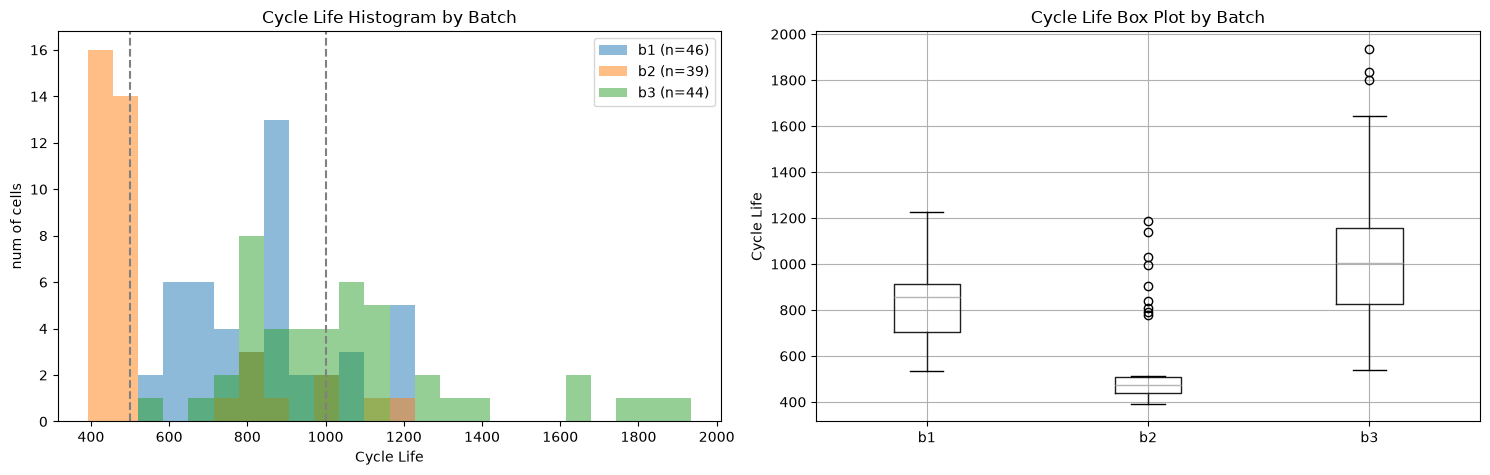

life_group  short(<500)   mid  long(>1000)
batch                                     
b1                  0.0  78.3         21.7
b2                 71.8  20.5          7.7
b3                  0.0  47.7         52.3 

       count    mean    std    min    25%     50%     75%     max
batch                                                            
b1      46.0   845.0  185.0  534.0  703.0   858.0   914.0  1227.0
b2      39.0   566.0  222.0  392.0  440.0   472.0   508.0  1186.0
b3      44.0  1060.0  314.0  541.0  828.0  1006.0  1155.0  1935.0

[IQR 이상치 셀]
      cell batch                       policy  cycle_life     C_avg     QD_c2  \
53    b2c7    b2  4.8C(80%)-4.8C-newstructure       777.0  4.800000  1.090478   
54    b2c8    b2    5.2C(58%)-4C-newstructure       904.0  4.803695  1.090633   
55    b2c9    b2  5.6C(26%)-4.5C-newstructure       791.0  4.806867  1.094971   
78   b2c32    b2  4.8C(80%)-4.8C-newstructure       809.0  4.800000  1.088156   
79   b2c33    b2    5.2C(58%)-4C-ne

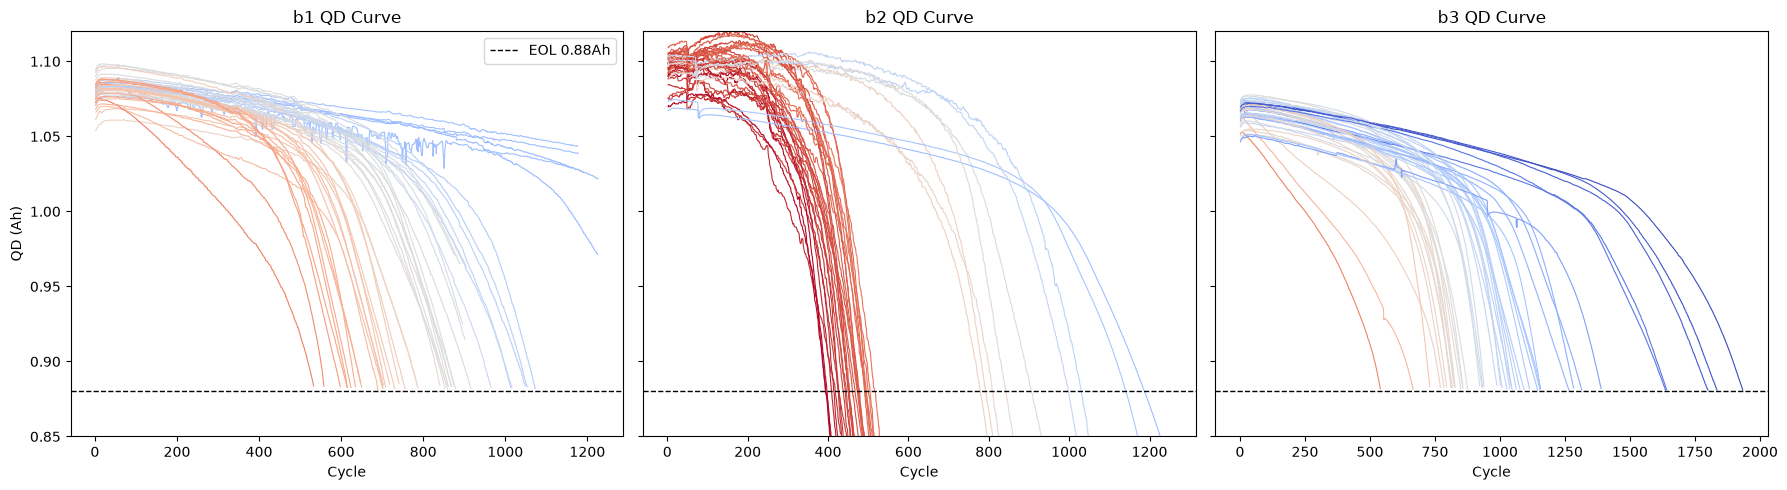

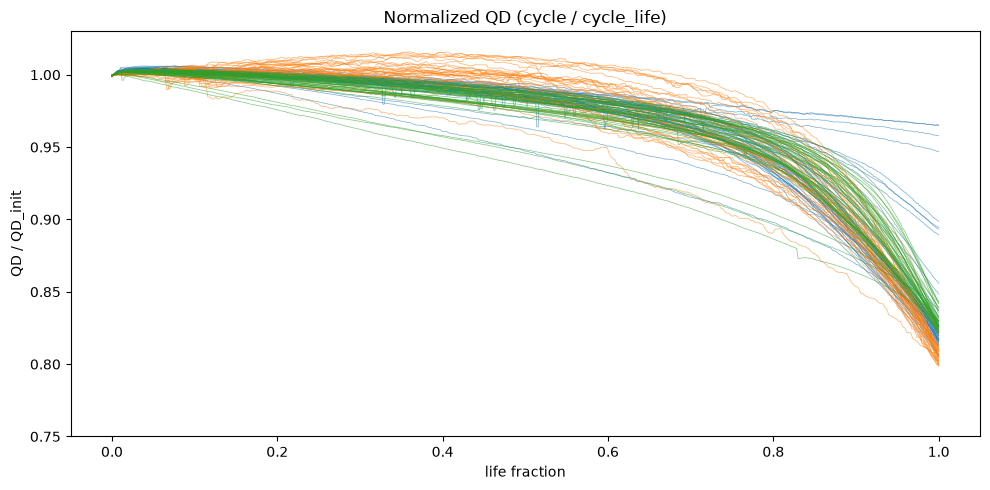

       count  mean   std   min   25%   50%   75%   max
batch                                                 
b1      46.0  0.73  0.10  0.35  0.73  0.75  0.77  0.82
b2      39.0  0.74  0.05  0.59  0.71  0.74  0.77  0.82
b3      44.0  0.80  0.04  0.69  0.78  0.79  0.82  0.87
knee vs cycle_life Pearson r = 0.953


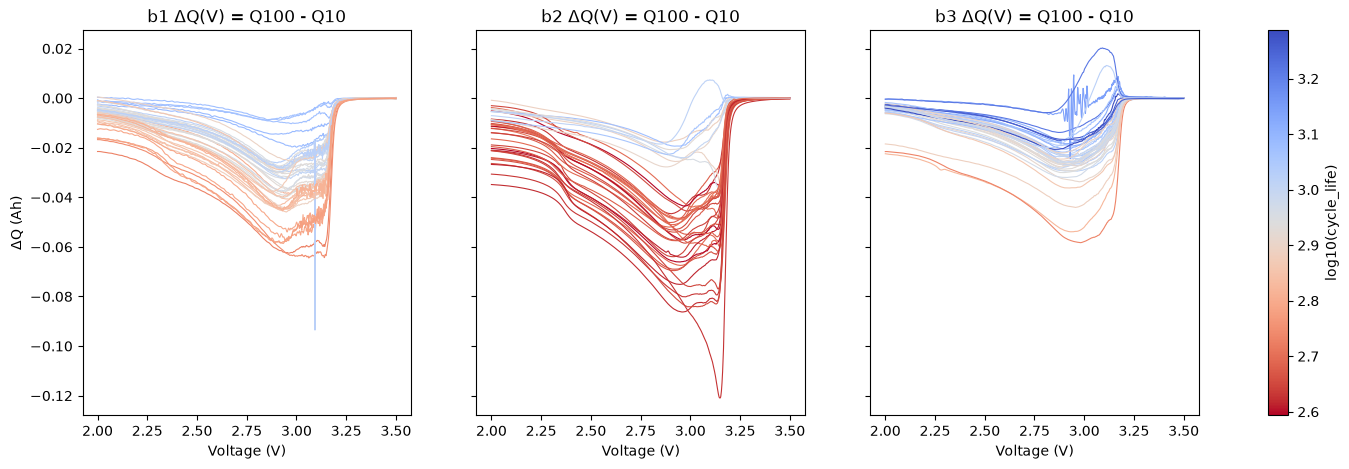

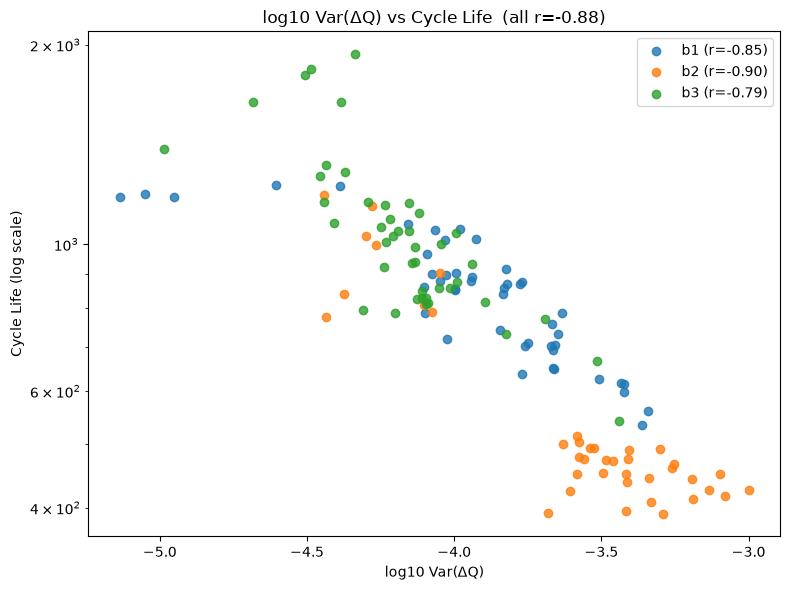

       dQ_logvar  dQ_min  dQ_mean  dQ_skew  dQ_kurt
group                                              
long      -4.358  -1.687   -2.115   -0.198   -0.590
mid       -3.887  -1.458   -1.811   -0.164   -1.192
short     -3.381  -1.213   -1.530    0.022   -1.218


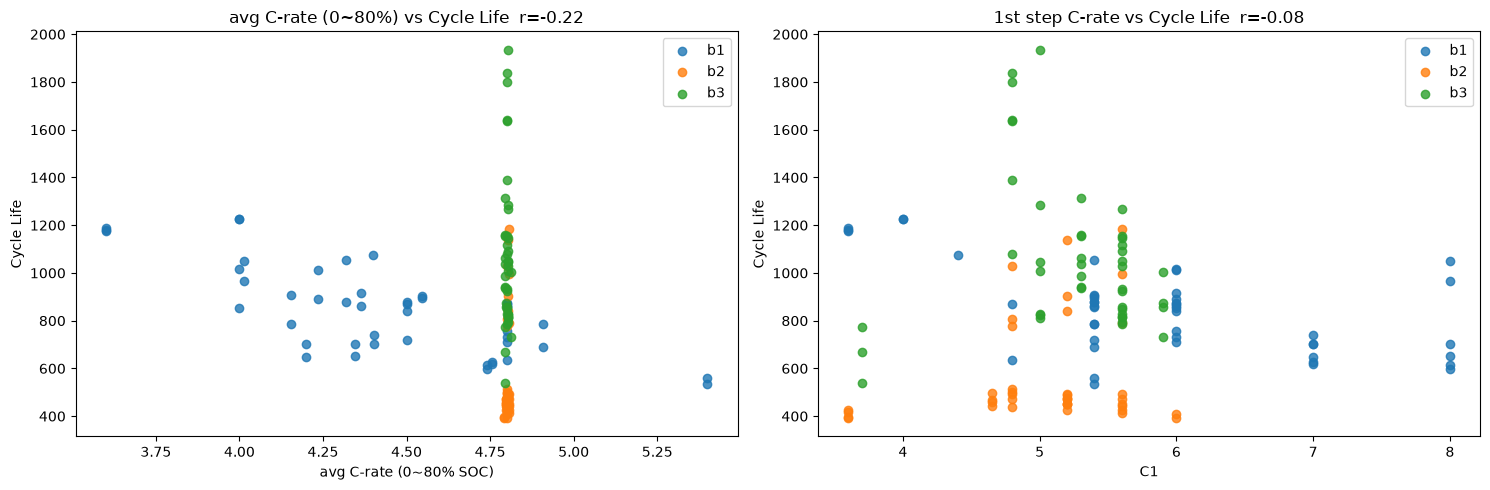

[정책 내 편차가 큰 정책 Top 10] - 같은 조건인데 수명이 다른 경우
                                     mean    std  count
batch policy                                           
b3    5C(67%)-4C-newstructure      1106.0  403.0      7
      4.8C(80%)-4.8C-newstructure  1564.0  286.0      6
b2    5.6C(26%)-4.5C-newstructure   991.0  198.0      3
b3    5.9C(60%)-3.1C-newstructure   866.0  192.0      2
      5.6C(19%)-4.6C-newstructure  1001.0  175.0      8
b1    4.8C(80%)-4.8C                753.0  165.0      2
b2    5.2C(58%)-4C-newstructure     962.0  158.0      3
      4.8C(80%)-4.8C-newstructure   872.0  137.0      3
b3    5.6C(36%)-4.3C-newstructure   931.0  135.0      8
      5.3C(54%)-4C-newstructure    1074.0  130.0      8

[파싱 안 된 정책] []
[log10(cycle_life)와의 Pearson 상관 : 배치별]
                    b1    b2    b3   all
dQ_logvar        -0.85 -0.90 -0.79 -0.88
dQ_min           -0.74 -0.86 -0.77 -0.84
dQ_mean          -0.83 -0.87 -0.67 -0.83
QD_c2             0.10 -0.23  0.17 -0.58
chargetime_mean   0.72 -0

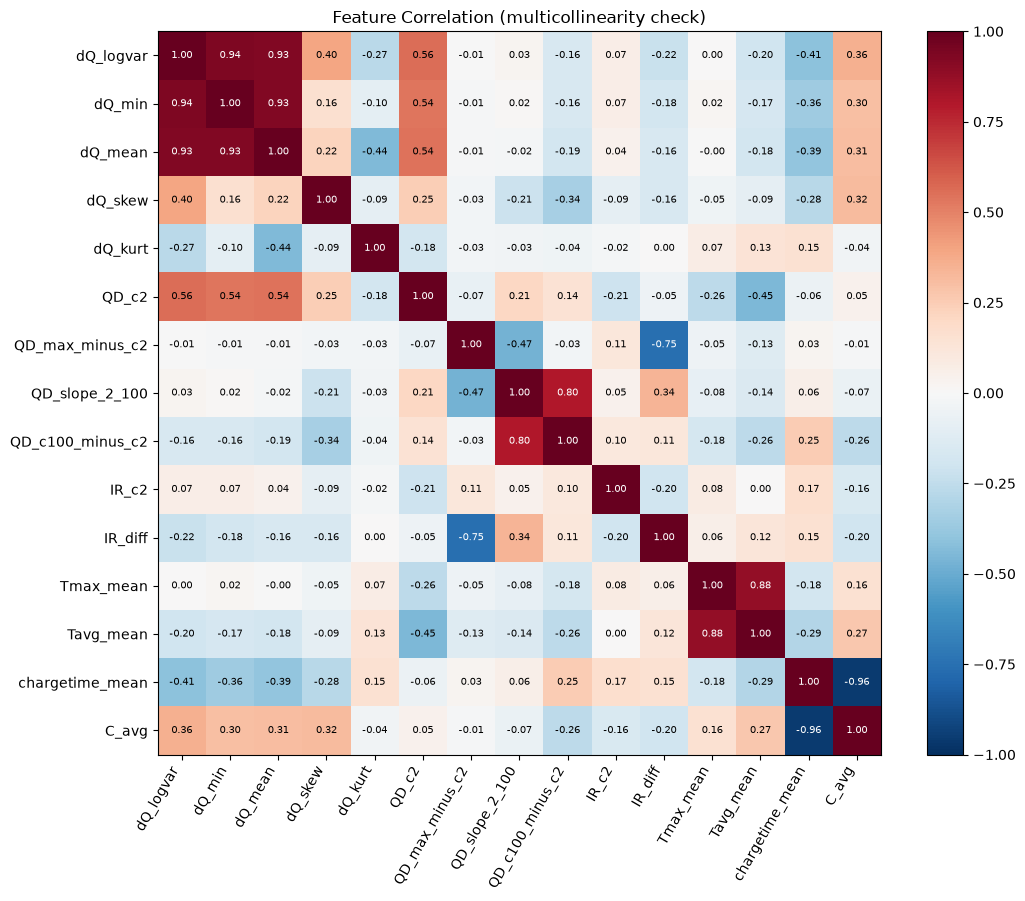

[|r| > 0.8 피처 쌍]
chargetime_mean  C_avg              -0.96
dQ_logvar        dQ_min              0.94
dQ_min           dQ_mean             0.93
dQ_logvar        dQ_mean             0.93
Tmax_mean        Tavg_mean           0.88
QD_slope_2_100   QD_c100_minus_c2    0.80
dtype: float64


In [3]:
%run -i ../src/eda.py